In [147]:
import pandas as pd                    # 데이터 분석에 적합한 새로운 자료구조 2개를 제공
import numpy as np                     # 행렬연산을 비롯한 수학적인 연산
import matplotlib.pyplot as plt        # 시각화 기본 모듈
import seaborn as sns                  # plt 도우미 

In [ ]:
# 엑셀을 DF로 바꾸기
# 컬럼 => 인덱스 => 데이터값

# pd의 주요 기능들
# 시리즈의 연산
# 정렬과 필터링
# apply
# groupby, pivot
# merge

In [53]:
grad_df = pd.read_excel(r"C:\Users\KDA\Desktop\DATA_ANALYSIS\OFFICIAL\grad_df.xlsx")
tip_df = sns.load_dataset('tips')

In [54]:
tip_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [60]:
# 시리즈의 연산 - 팁 비율 계산
tip_df['tip_ratio'] = tip_df['tip'] / tip_df['total_bill'] * 100

In [61]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426


In [58]:
# 여자고 total_bill을 15달러 이상 낸 사람 중 tip 절대값을 크게 낸 사람 top20
temp = tip_df[(tip_df['total_bill'] > 15) & (tip_df['sex'] == 'Female')]
temp.sort_values('tip', ascending=False)[:20]

,total_bill,tip,sex,smoker,day,time,size
214,28.17,6.50,Female,Yes,Sat,Dinner,3
52,34.81,5.20,Female,No,Sun,Dinner,4
85,34.83,5.17,Female,No,Thur,Lunch,4
155,29.85,5.14,Female,No,Sun,Dinner,5
197,43.11,5.00,Female,Yes,Thur,Lunch,4
73,25.28,5.00,Female,Yes,Sat,Dinner,2
11,35.26,5.00,Female,No,Sun,Dinner,4
143,27.05,5.00,Female,No,Thur,Lunch,6
238,35.83,4.67,Female,No,Sat,Dinner,3
93,16.32,4.30,Female,Yes,Fri,Dinner,2


In [63]:
# apply
# 한 열의 모든 데이터에게 똑같은 코드를 적용
# tip_ratio가 15%를 넘어가면 'big_tip', 아니면 'small_tip'

def get_tipCate(x):
    if x >= 15:
        return 'bit_tip'
    else :
        return 'small_tip'

tip_df['tip_cate'] = tip_df['tip_ratio'].apply(get_tipCate)

In [64]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio,tip_cate
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,small_tip
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,bit_tip
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,bit_tip
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,small_tip
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,small_tip
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,bit_tip
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,small_tip
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,small_tip
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,small_tip


In [52]:
# groupby & pivot
# 카테고리 별로 데이터를 묶어서 집계
# 집계 - 여러개의 데이터를 하나의 대표값으로 표현(mean, sum, max, min, count, ...)

grad_df.groupby( 'sido' )['spc_R'].mean()

sido
강원    0.933726
경기    1.847976
경남    1.091880
경북    0.625195
광주    0.824606
대구    0.859265
대전    1.991717
부산    3.314950
서울    2.235116
세종    2.550332
울산    2.072260
인천    2.333412
전남    0.603260
전북    0.902938
제주    2.139783
충남    0.843625
충북    1.227778
Name: spc_R, dtype: float64

In [70]:
# 성별에 따른 평균 팁
tip_df.groupby(['sex', 'smoker'])['tip'].mean()

## groupby의 결과는 series이므로 1차원으로 나온다.

sex     smoker
Male    Yes       3.051167
        No        3.113402
Female  Yes       2.931515
        No        2.773519
Name: tip, dtype: float64

In [73]:
# pivot - 카테고리 별로 집계, 결과 2차원 - dataframe

pd.pivot_table( tip_df, index = 'sex', columns = 'smoker', values = 'tip', aggfunc = 'mean')

smoker,Yes,No
sex,,
Male,3.051167,3.113402
Female,2.931515,2.773519


In [111]:
# merge
# 위도 경도 코드 학교명
# lat  log code name
sch_inform = pd.read_excel(r"C:\Users\KDA\Desktop\DATA_ANALYSIS\OFFICIAL\공시대상학교정보(전체).xlsx")

In [113]:
sch_inform.columns

Index(['시도교육청', '지역교육청', '지역', '정보공시 \n 학교코드', '학교명', '학교급코드', '설립구분', '학교특성',
       '분교여부', '설립유형', '주야구분', '개교기념일', '설립일', '법정동코드', '주소내역', '상세 \n 주소내역',
       '우편번호', '학교도로명 \n 우편번호', '학교도로명 \n 주소', '학교도로명 \n 상세주소', '위도', '경도',
       '전화번호', '팩스번호', '홈페이지 \n 주소', '남녀공학 \n 구분'],
      dtype='str')

In [114]:
sch_inform2 = sch_inform[
    ['위도', '경도', '학교명', '정보공시 \n 학교코드']
]

sch_inform2

,위도,경도,학교명,정보공시 \n 학교코드
0,37.490739,127.015424,서울교육대학교부설초등학교,S000003511
1,37.577017,127.003091,서울대학교사범대학부설초등학교,S000003563
2,37.481618,127.058738,서울개원초등학교,S010000737
3,37.486214,127.057742,서울개일초등학교,S010000738
4,37.481193,127.051755,서울구룡초등학교,S010000741
...,...,...,...,...
12179,33.488117,126.542748,제주영지학교,S170000512
12180,33.450047,126.434217,제주영송학교,S170000513
12181,33.291338,126.593310,서귀포온성학교,S170000790
12182,33.480030,126.479518,제주제일고등학교부설방송통신고등학교,S170000155


In [115]:
sch_inform2.columns = ['lat', 'log', 'name_y', 'code']

sch_inform2

,lat,log,name_y,code
0,37.490739,127.015424,서울교육대학교부설초등학교,S000003511
1,37.577017,127.003091,서울대학교사범대학부설초등학교,S000003563
2,37.481618,127.058738,서울개원초등학교,S010000737
3,37.486214,127.057742,서울개일초등학교,S010000738
4,37.481193,127.051755,서울구룡초등학교,S010000741
...,...,...,...,...
12179,33.488117,126.542748,제주영지학교,S170000512
12180,33.450047,126.434217,제주영송학교,S170000513
12181,33.291338,126.593310,서귀포온성학교,S170000790
12182,33.480030,126.479518,제주제일고등학교부설방송통신고등학교,S170000155


In [119]:
sch_inform2.isna().sum()

lat       1
log       1
name_y    0
code      0
dtype: int64

In [120]:
sch_inform2[sc_df.isna().any(axis=1)]

,lat,log,name_y,code
3901,NaN,NaN,양지초등학교,S080000104


In [122]:
sch_inform2.columns

Index(['lat', 'log', 'name_y', 'code'], dtype='str')

In [124]:
# merge
# 한번에 여러개의 df를 가로로 붙여 줌
# how => 교집합, 합집합, 한쪽기준
total_df = pd.merge( grad_df, sch_inform2, left_on = 'code', right_on = 'code', how = 'left')

In [125]:
total_df

,reg,code,name,grad_N,sci_N,fl_N,spc_N,spc_R,sido,lat,log,name_y
0,서울특별시 성북구,S000003514,서울대학교사범대학부설중학교,234,4,5,9,3.846154,서울,37.596201,127.039164,서울대학교사범대학부설중학교
1,서울특별시 종로구,S000003562,서울대학교사범대학부설여자중학교,172,0,8,8,4.651163,서울,37.577928,127.003899,서울대학교사범대학부설여자중학교
2,서울특별시 강남구,S010000698,개원중학교,214,2,9,11,5.140187,서울,37.491641,127.071415,개원중학교
3,서울특별시 서초구,S010000700,경원중학교,310,5,4,9,2.903226,서울,37.511582,127.009017,경원중학교
4,서울특별시 강남구,S010000701,구룡중학교,256,3,4,7,2.734375,서울,37.486153,127.056123,구룡중학교
...,...,...,...,...,...,...,...,...,...,...,...,...
3425,제주특별자치도 제주시,S170000838,오름중학교,193,0,5,5,2.590674,제주,33.516620,126.584598,오름중학교
3426,제주특별자치도 제주시,S170000844,탐라중학교,298,1,1,2,0.671141,제주,33.491686,126.545093,탐라중학교
3427,제주특별자치도 제주시,S170000512,제주영지학교,12,0,0,0,0.000000,제주,33.488117,126.542748,제주영지학교
3428,제주특별자치도 제주시,S170000513,제주영송학교,21,0,0,0,0.000000,제주,33.450047,126.434217,제주영송학교


In [126]:
# 지도 위에 데이터 표시
# folium

import folium

In [144]:
# 지도 - 도화지
test_map = folium.Map(
    location=[37, 127],
    zoom_start=10,
    tiles='OpenStreetMap'
)

test_map.save(r'C:\Users\KDA\Desktop\test.html')

# 데이터 시각화 정리

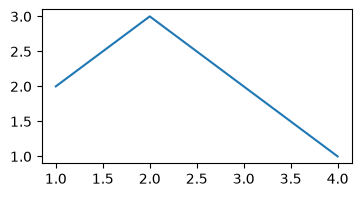

In [150]:
plt.figure(figsize=(4,2))  # 시작점
# figsize

plt.plot([1, 2, 3, 4], [2, 3, 2, 1])

plt.show()    # 마침표

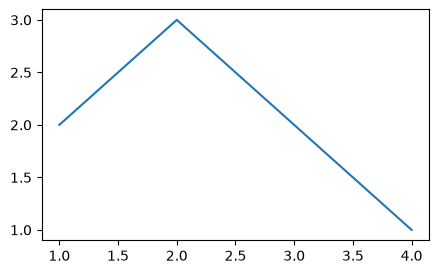

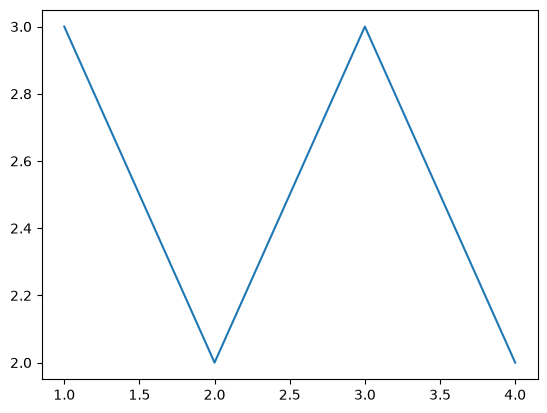

In [151]:
아래 코드를 기반으로 시각화를 더 풍부하고 이쁘게 만들어줘

plt.figure(figsize=(5,3))  # 시작점
# figsize

plt.plot([1, 2, 3, 4], [2, 3, 2, 1])

plt.show()

plt.plot([1,2,3,4],[3,2,3,2])

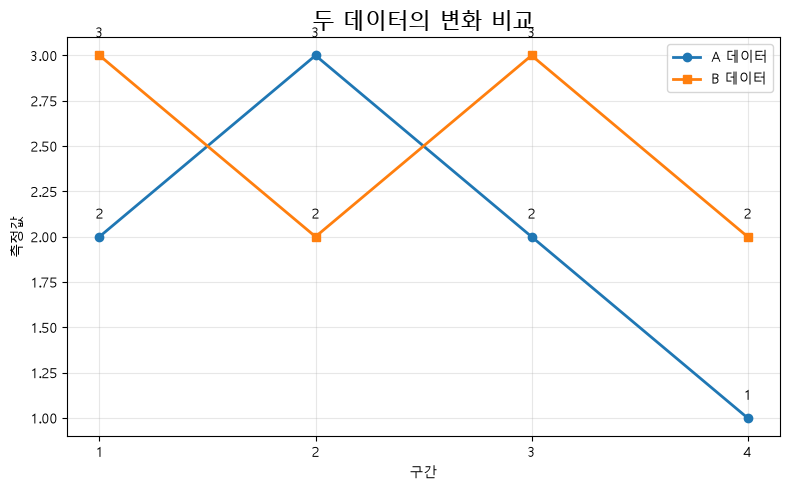

In [154]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

x = [1, 2, 3, 4]
y1 = [2, 3, 2, 1]
y2 = [3, 2, 3, 2]

plt.figure(figsize=(8, 5))

plt.plot(x, y1, marker='o', linewidth=2, label='A 데이터')
plt.plot(x, y2, marker='s', linewidth=2, label='B 데이터')

for i in range(len(x)):
    plt.text(x[i], y1[i] + 0.1, y1[i], ha='center')
    plt.text(x[i], y2[i] + 0.1, y2[i], ha='center')

plt.title('두 데이터의 변화 비교', fontsize=16)
plt.xlabel('구간')
plt.ylabel('측정값')

plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

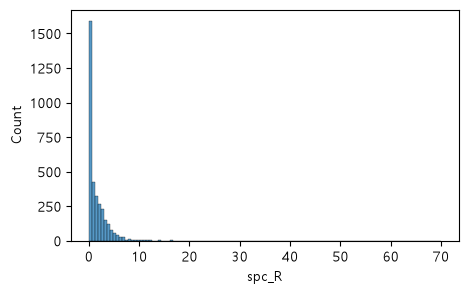

In [156]:
plt.figure(figsize=(5,3))
sns.histplot(total_df, x='spc_R')
plt.show()

## 시각화의 목적 : 이쁜 장표X
- => 데이터를 관찰할 수 있는 유일한 수단
- 데이터 종류에 따라 어떤 시각화를 사용해서 관찰할 것인가를 정리
- 데이터 종류
      - 범주형 데이터
      - 수치형 데이터

### 1. 범주형 데이터
- 카테고리 별로 데이터 어디에 몰려 있고 어떻게 퍼져 있는지 알아보자
- sns.countplot

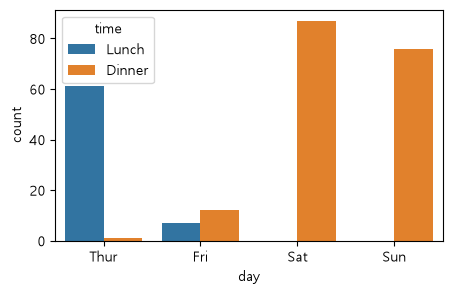

In [160]:
plt.figure(figsize=(5,3))
sns.countplot(tip_df, x = 'day', hue = 'time')
plt.show()

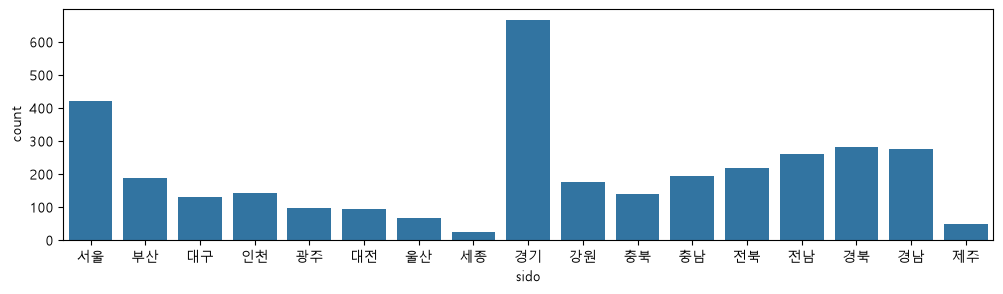

In [162]:
plt.rcParams['font.family'] = 'Malgun Gothic'

# plt.figure(figsize=(5,3))
plt.figure(figsize=(12,3))

sns.countplot(total_df, x='sido')

plt.show()

In [ ]:
범주형

수치형

In [158]:
total_df['name']

0         서울대학교사범대학부설중학교
1       서울대학교사범대학부설여자중학교
2                  개원중학교
3                  경원중학교
4                  구룡중학교
              ...       
3425               오름중학교
3426               탐라중학교
3427              제주영지학교
3428              제주영송학교
3429             서귀포온성학교
Name: name, Length: 3430, dtype: str

### 2. 수치형 데이터
- 어디에 데이터가 몰려있고, 어떻게 퍼져있는지 (분포)
- 히스토그램, sns.histplot( tip_df, x = 'tip')
- plt.show()

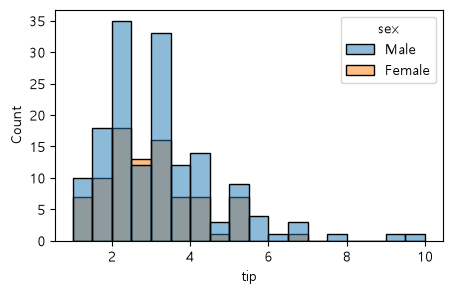

In [165]:
plt.figure(figsize=(5,3))
sns.histplot(tip_df,x='tip',hue='sex')
plt.show()

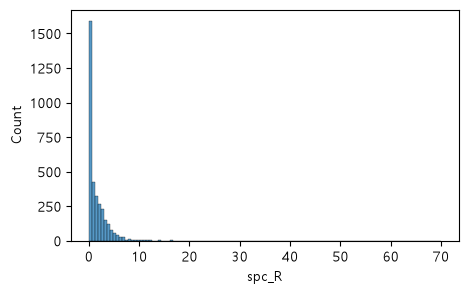

In [163]:
plt.figure(figsize=(5,3))

sns.histplot( total_df, x='spc_R')

plt.show()

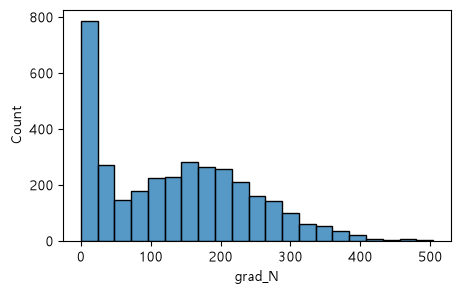

In [167]:
plt.figure(figsize=(5,3))

sns.histplot( total_df, x='grad_N')

plt.show()

# 몰려 있는 곳이 두곳? => 카테고리를 두개로 나눠볼까

In [ ]:
# 졸업생 숫자가 2개의 범주로 나눌 수 있지 않을까?!
# 졸업생이 180정도에 몰려있고 좌우로 퍼져있는 => 대도시
# 졸업생이 10명 미만에 몰려있고 꼬리가 오른쪽으로 긴 => 소도시

In [168]:
total_df['sido'].unique()

<ArrowStringArray>
['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기', '강원', '충북', '충남', '전북',
 '전남', '경북', '경남', '제주']
Length: 17, dtype: str

In [179]:
def get_sidoCate(x) :
    if x in ['서울', '부산', '대구', '인천', '광주', '대전', '울산', '세종', '경기']:
        return 'big_city'
    else :
        return 'small_city'

total_df['is_bigCity'] = total_df['sido'].apply(get_sidoCate)

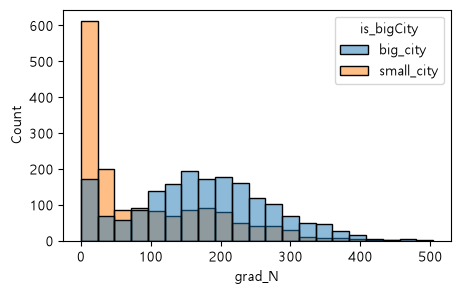

In [180]:
plt.figure(figsize=(5,3))

sns.histplot( total_df, x='grad_N', hue = 'is_bigCity')

plt.show()

In [181]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 4))

# # big_city
# plt.subplot(1, 2, 1)
# plt.hist(
#     grad_df[grad_df['sido_cate'] == 'big_city']['원하는컬럼'],
#     bins=10
# )
# plt.title('Big City')
# plt.xlabel('값')
# plt.ylabel('빈도')

# # small_city
# plt.subplot(1, 2, 2)
# plt.hist(
#     grad_df[grad_df['sido_cate'] == 'small_city']['원하는컬럼'],
#     bins=10
# )
# plt.title('Small City')
# plt.xlabel('값')
# plt.ylabel('빈도')

# plt.tight_layout()
# plt.show()

In [173]:
grad_df.columns

Index(['reg', 'code', 'name', 'grad_N', 'sci_N', 'fl_N', 'spc_N', 'spc_R',
       'sido'],
      dtype='str')

### 3. 범주형 * 수치형 데이터
- 카테고리 별로 수치형 데이터의 분포
- sns.boxplot, sns.violinplot 사용

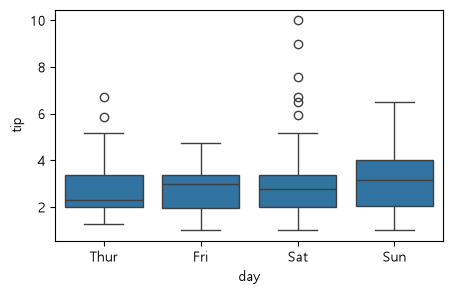

In [183]:
plt.figure(figsize=(5,3))

sns.boxplot(tip_df, x = 'day', y = 'tip')

plt.show()

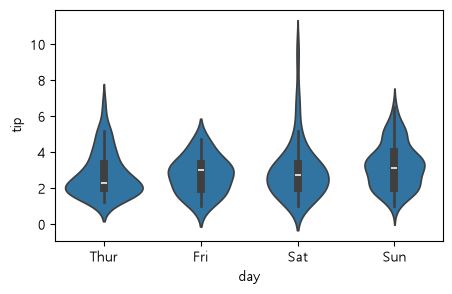

In [184]:
plt.figure(figsize=(5,3))

sns.violinplot(tip_df, x = 'day', y = 'tip')

plt.show()

In [ ]:
### 4. 수치형 * 수치형 데이터 관계
- 두 데이터가 만나는 지점마다 점을찍어서 두 데이터가 어떻게 퍼져있는가 확인
- 산포도
- sns.scatterplot, plt.scatterplot

In [185]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio,tip_cate
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,small_tip
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,bit_tip
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,bit_tip
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,small_tip
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,small_tip
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,bit_tip
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,small_tip
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,small_tip
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,small_tip


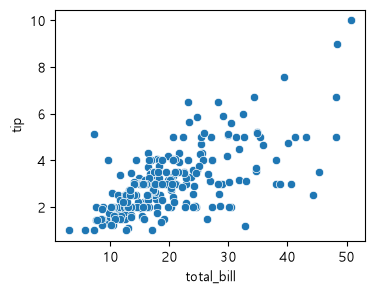

In [186]:
plt.figure(figsize=(4,3))

sns.scatterplot(tip_df, x = 'total_bill', y = 'tip')

plt.show()

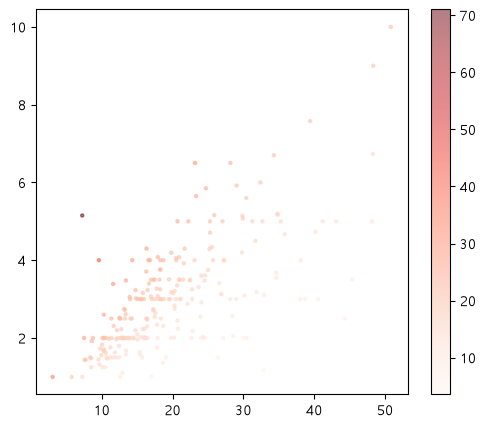

In [194]:
plt.figure(figsize=(6,5))

# plt.scatter(tip_df['total_bill'], tip_df['tip'], s = 5, alpha = 0.5, c='skyblue') 
plt.scatter(tip_df['total_bill'], tip_df['tip'], s = 5, alpha = 0.5, c = tip_df['tip_ratio'], cmap = 'Reds') 
# 사이즈 조절도 가능(s), 투명도 조절도 가능 0 ~ 1 (alpha), 색상 조절도 가능 (c)

plt.colorbar()

plt.show()

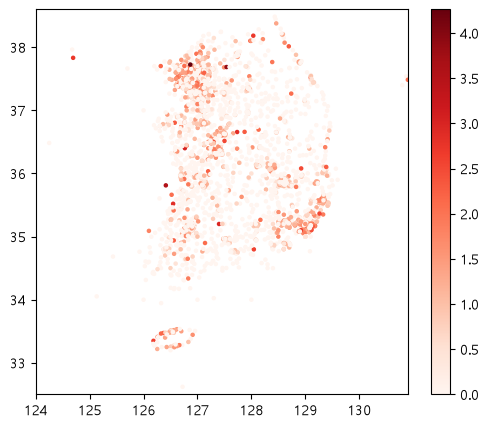

In [199]:
plt.figure(figsize=(6,5))

plt.scatter(total_df['log'], total_df['lat'], s=5,
           c=np.log1p(total_df['spc_R']),cmap='Reds')
plt.colorbar()
plt.xlim([124, 130.9])
plt.ylim([32.5,38.6])

plt.show()

In [200]:
tip_df

,total_bill,tip,sex,smoker,day,time,size,tip_ratio,tip_cate
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,small_tip
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,bit_tip
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,bit_tip
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,small_tip
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,small_tip
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,20.392697,bit_tip
240,27.18,2.00,Female,Yes,Sat,Dinner,2,7.358352,small_tip
241,22.67,2.00,Male,Yes,Sat,Dinner,2,8.822232,small_tip
242,17.82,1.75,Male,No,Sat,Dinner,2,9.820426,small_tip


# 머신러닝

In [202]:
iris_df = sns.load_dataset('iris')

# 앞에 있는 네가지를 통해 species를 예측하는 모델을 만들겠다.
# 데이터 종류 파악 >> 
# 카테고리 counterplot/ 수치형 histogram /
# boxplot diaryplot /숫자& 숫자 산포도

1. EDA(탐색적 데이터 분석)
- 데이터 시각화를 엄청 하면서 데이터를 관찰...

2. Feature Engineering
- 데이터 가공

3. ML 모델 사용

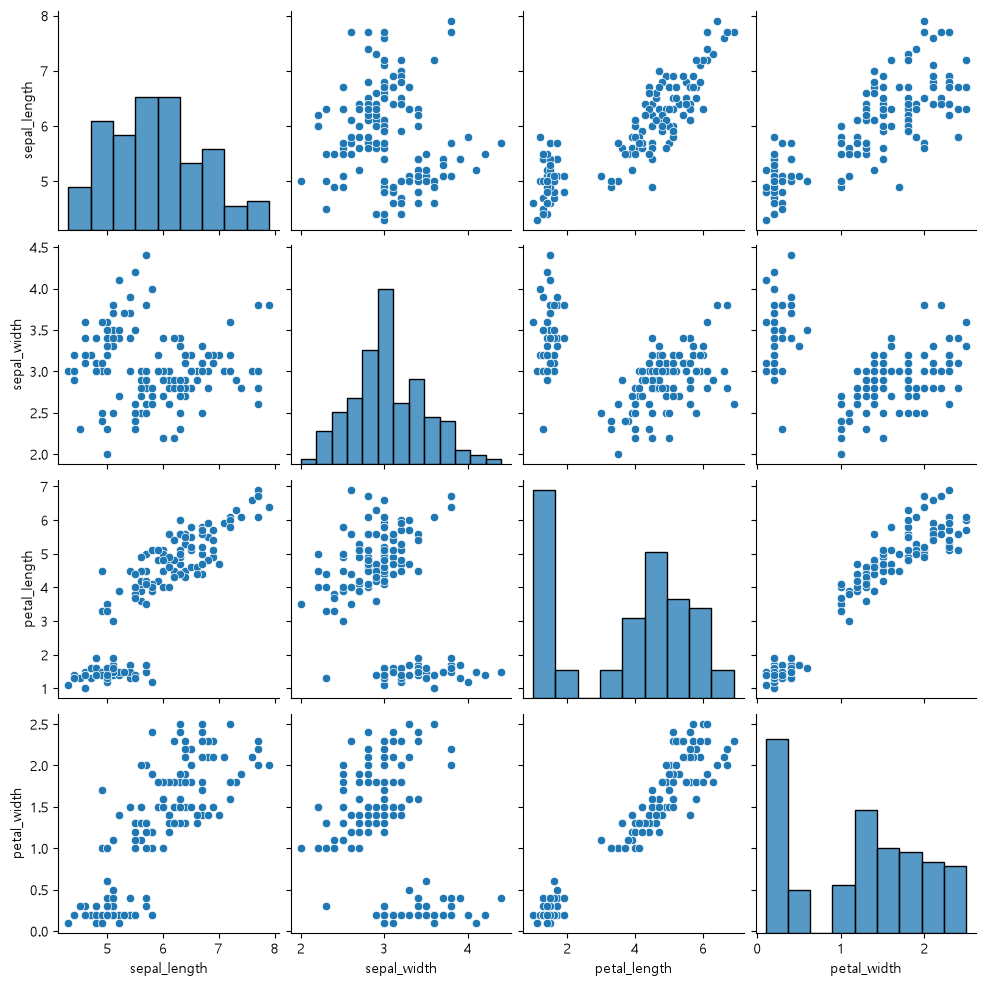

In [203]:
sns.pairplot(iris_df)
plt.show()

In [ ]:
# hue를 사용해서 species

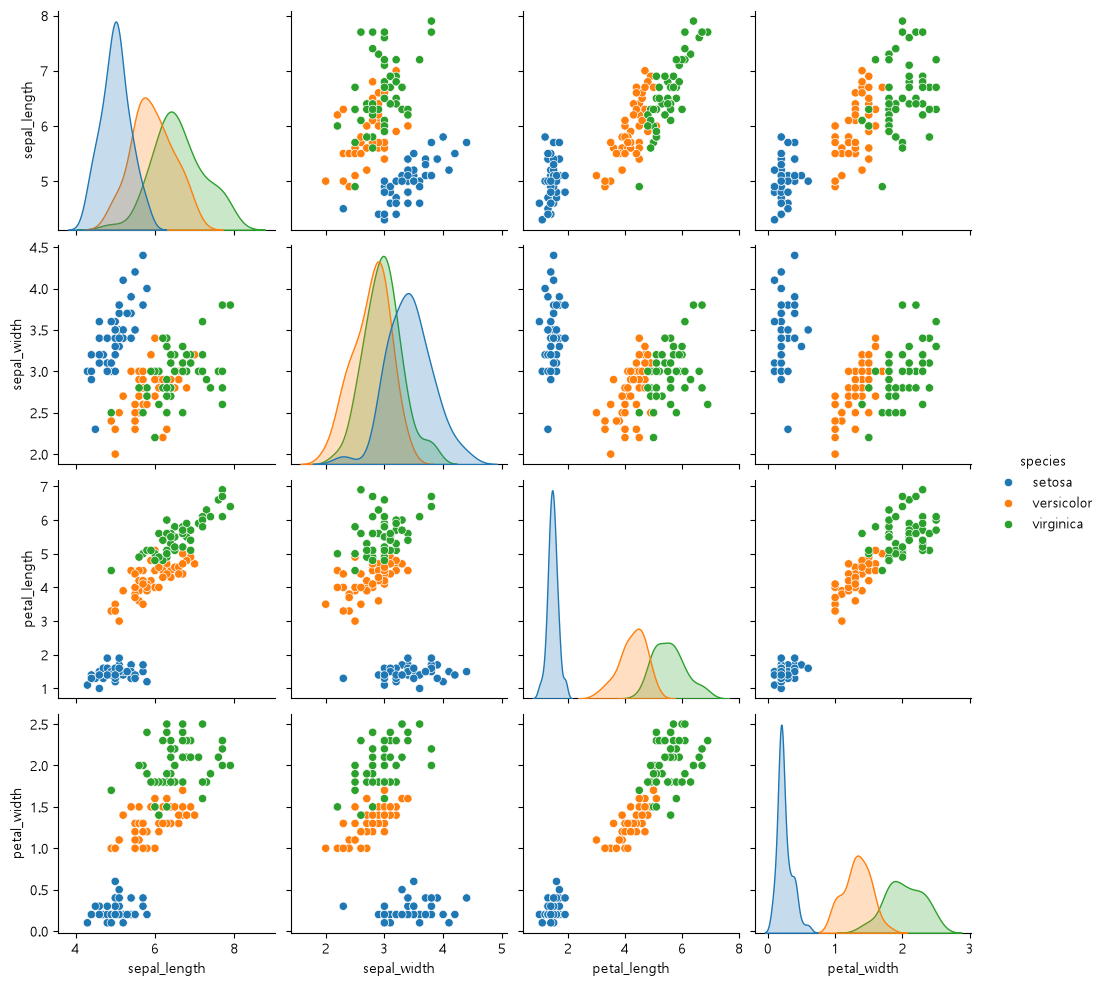

In [206]:
sns.pairplot(iris_df,hue='species')
plt.show()

In [207]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [ ]:
K - Nearest - Neighbors (KNN)

주변의 데이터를 살펴보자
주변 => 거리가 가까운거

새로운 데이터 등장!
기존의 거리 계산 => 거리가 짧은거 K개를 가져옴
K개를 가지고 얘네들의 최빈도값을 예측값으로 사용

파란색 7, 초록색 3 => 파란색

# 모델을 만드는것보다 호환성을 생각해서 결합하는게 중요함

=> 사이킷런!

In [ ]:
# 사이킷런 사용법
# 1. 모델 생성
# 2. 모델 훈련
# 3. 검증, 예측

In [208]:
# sklearn이 무겁고 복잡하기 때문에 풀로 부르지 않음
import sklearn

In [209]:
from sklearn.neighbors import KNeighborsClassifier 

In [211]:
# 1. 모델 생성
knn = KNeighborsClassifier()

In [217]:
# 2. 모델 훈련
# 사이킷런 모델은 데이터를 feature와 target으로 나누어서 넣어야 한다
# target(종속변수) : 우리가 예측하고 싶은 대상, 1차원, Series
# feature(독립변수) : 무언가를 예측하기 위한 단서, 2차원, DataFrame

y = iris_df['species']
X = iris_df.iloc[:,:-1]

_ = knn.fit(X, y)
# knn.fit( iris_df )

In [220]:
# 3. 검증, 예측
knn.predict( [[5.0, 3.4, 1.42, 0.19]]) 
# knn.predict( [5.0, 3.4, 1.42, 0.19])

C:\Users\KDA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['setosa'], dtype=object)

In [221]:
iris_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [230]:
# 훈련용 데이터 // 검증용 데이터
from sklearn.model_selection import train_test_split

train_x, valid_x, train_y, valid_y = train_test_split( X, y, test_size = 0.2, random_state = 1, stratify = y )

In [ ]:
# 논문에서는 재검증이 중요함

In [226]:
train_x

,sepal_length,sepal_width,petal_length,petal_width
91,6.1,3.0,4.6,1.4
135,7.7,3.0,6.1,2.3
69,5.6,2.5,3.9,1.1
128,6.4,2.8,5.6,2.1
114,5.8,2.8,5.1,2.4
...,...,...,...,...
133,6.3,2.8,5.1,1.5
137,6.4,3.1,5.5,1.8
72,6.3,2.5,4.9,1.5
140,6.7,3.1,5.6,2.4


In [231]:
train_y.value_counts()

species
setosa        40
virginica     40
versicolor    40
Name: count, dtype: int64

In [232]:
<!-- 1 - 5
0 - 95
0 - 80
0
1 -->

# 1. 모델 생성
knn = KNeighborsClassifier()

# 2. 훈련
_ = knn.fit(train_x, train_y)

SyntaxError: invalid syntax (3141000947.py, line 1)

In [236]:
# 3. 검증
# knn.predict(valid_x) == valid_y
knn.score(valid_x, valid_y)

0.9666666666666667

In [ ]:
# 주변에 몇 개의 데이터를 볼 것인가?!
# 데이터에 의해 계산되는 것이 아니라 사용자가 직접 세팅해줘야 하는 파라미터
# 하이퍼 파라미터!
# 모델을 주어진 데이터에 얼마나 꽉 조일것이냐를 결정
# 데이터 패턴이 복잡 => 꽉 조여야 함, 잘못하다 오버피팅 됨
# 데이터 패턴이 단순 => 느슨하게 조여야 함, 잘못하다 언더피팅 됨

In [ ]:
K를 작게하면 ... => 쪼이는것!
K를 크게하면 ... => 느슨하게 하는것!

In [ ]:
뭔가를 예측 <= 얘랑 관련이 있을 것 같은 feature를 수집

In [ ]:
X,y =>  EDA

In [ ]:
ML <= X, y(8 : 2)

In [237]:
ML(새로운 X) => y예측

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1683401.py, line 1)

In [240]:
from sklearn.model_selection import cross_val_score

KNeighborsClassifier(n_neighbors = 15)
cross_val_score(knn, train_x, train_y, cv = 4).mean()

np.float64(0.9583333333333334)

In [243]:
score_list = []
for k in range(1,31) :
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, train_x, train_y, cv = 4).mean()
    score_list.append(score)

In [244]:
score_list

[np.float64(0.9666666666666667),
 np.float64(0.9583333333333334),
 np.float64(0.9833333333333334),
 np.float64(0.9666666666666667),
 np.float64(0.9583333333333334),
 np.float64(0.9666666666666667),
 np.float64(0.9833333333333334),
 np.float64(0.9750000000000001),
 np.float64(0.9833333333333334),
 np.float64(0.9750000000000001),
 np.float64(0.9833333333333334),
 np.float64(0.9833333333333334),
 np.float64(0.9833333333333334),
 np.float64(0.9583333333333334),
 np.float64(0.9416666666666667),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.9583333333333333),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.9416666666666667),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.95),
 np.float64(0.9416666666666667),
 np.float64(0.9333333333333333),
 np.float64(0.925)]

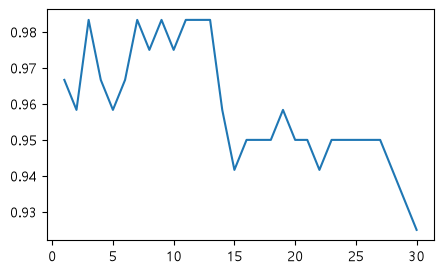

In [246]:
plt.figure(figsize=(5,3))
plt.plot(range(1,31), score_list)
plt.show()

In [ ]:
# 결과가 무조건 좋은 이유 => iris는 완벽한 데이터
# 1. 데이터의 패턴이 너무 강력!
# 2. 데이터의 가공이 필요가 없는 데이터...
    인코딩, 스케일링, ...

In [248]:
iris_df['sepal_length'] * 1000

0      5100.0
1      4900.0
2      4700.0
3      4600.0
4      5000.0
        ...  
145    6700.0
146    6300.0
147    6500.0
148    6200.0
149    5900.0
Name: sepal_length, Length: 150, dtype: float64

In [250]:
y = iris_df['species']
X = iris_df.iloc[:,:-1]
train_x, valid_x, train_y, valid_y = train_test_split( X, y, test_size = 0.2, random_state = 1, stratify = y )

In [ ]:
# 1. EDA
# 2. Feature Engineering
# 3. ML모델을 이용 

# 웹 크롤링
- 웹에 있는 데이터를 자동으로 수집


In [252]:
# url 세팅 ( 요청 & 응답 )
url = 'https://search.daum.net/search?w=news&nil_search=btn&DA=STC&enc=utf8&cluster=y&cluster_page=1&q=%EC%82%BC%EC%84%B1%EC%A0%84%EC%9E%90&p=1&sort=recency'


In [255]:
# 요청
# 데이터를 달라고 하는 요청 : get, post
import requests
resp = requests.get(url)

In [256]:
# 응답 안에 코드
resp.text

'<!doctype html>\n<html xmlns="http://www.w3.org/1999/xhtml" lang="ko">\n<head profile="http://a9.com/-/spec/opensearch/1.1/">\n<meta http-equiv="content-Type" content="text/html;charset=utf-8" />\n<meta http-equiv="X-UA-Compatible" content="IE=edge" />\n<meta name="autocomplete" content="off" />\n<meta name="referrer" content="always">\n<meta name="format-detection" content="telephone=no,address=no,email=no" />\n<meta property="og:title" content="삼성전자 &ndash; Daum 검색" />\n<meta property="og:url" content="https://search.daum.net/search?w=news&amp;nil_search=btn&amp;DA=STC&amp;enc=utf8&amp;cluster=y&amp;cluster_page=1&amp;q=%EC%82%BC%EC%84%B1%EC%A0%84%EC%9E%90&amp;p=1&amp;sort=recency" />\n<meta property="og:description" content="Daum 검색에서 삼성전자에 대한 최신정보를 찾아보세요." />\n<meta property="og:image" content="https://search1.daumcdn.net/search/statics/common/img/2026/daum_og.png" />\n<meta property="og:site_name" content="다음검색" />\n<link href="https://search1.daumcdn.net/search/statics/common/im

In [258]:
# 코드에서 데이터를 추출해서 정리(파싱)
import bs4

# str => bs
news_bs = bs4.BeautifulSoup( resp.text )

In [263]:
news_bs.find('strong', class_= 'tit-g clamp-g').text

'  멜콘, 다음 달 15일 코스닥 상장…"국내 넘어 해외 반도체 시장 공략"  '

In [267]:
# find_all => 똑같은 것들로 다 가져옴
# => 결과는 리스트로 묶여서 나옴
title_list = news_bs.find_all('strong', class_= 'tit-g clamp-g')

for title in title_list:
    print(title.text)

  멜콘, 다음 달 15일 코스닥 상장…"국내 넘어 해외 반도체 시장 공략"  
  호남 반도체 심장, 2030년 뛴다…전남광주, 첫 양산 가속 페달  
  허태정 "국가반도체연구소, 대전이 역할 맡겠다"  
  광주 반도체 산단 내년 상반기 착공…2030년 첫 양산 목표  
  (단독)단일종목 레버리지 '종목 확대' 대안 있었다…정부는 '삼전·하닉' 고집  
  삼성전자 DS 노조 추석 끝나면 다시 '성과급' 논의..내년 교섭안 정한다  
  아이폰18 프로 101만원…‘성지폰’ 해지 땐 위약금 65만원  
  국감증인 공방…與 '망신주기 안돼'·野 '팔비틀기 투자 밝혀야'  
  [마감시황]코스피, 2%대 출발 후 급제동…7000선 간신히 지켰다  
  코스피 장중 2%대 급등 후 상승폭 반납…7017.91 강보합  


In [274]:
sub_list = news_bs.find_all('p', class_ = 'conts-desc clamp-g2')

for title in sub_list:
    print(title.text)

  시스템이다. XPS는 ASML의 스캐너와 연동해 장비 내부에 깨끗하고 건조한 공기를 공급하는 정제 시스템이다. 주요 고객사는 삼성전자(005930), SK하이닉스(003600) 등이다. 두 회사 모두에 20년 이상 제품을 납품하고 있다. 지난해 매출 기준 두 고객사가 전체에서...  
  정주여건 개선까지 클러스터 조성의 핵심 과제를 한꺼번에 앞당기겠다는 구상이다. 이번 사업은 정부와 전남광주통합특별시, 삼성전자, SK하이닉스가 함께 추진하는 초대형 반도체 프로젝트다. 광주 군공항 이전부지 약 250만 평에 메모리 반도체 생산기지 4기 이상...  
  이를 300㎜ 공정으로 확대해 검증하지 못하면 고객사의 인증이나 생산 수율 확인, 공급망 진입으로 이어지기 어렵다고 설명했다. 삼성전자와 SK하이닉스의 300㎜ 시설은 자사 양산을 위한 설비인 만큼, 산업계 전반이 공동으로 활용할 수 있는 공공시설이 필요하다는...  
  생산시설 4기에 필요한 인력을 2만3천 명으로 추산하고 지역 대학 반도체학과와 반도체고 신설 등 인재 양성 방안도 추진합니다. 삼성전자와 SK하이닉스에는 기업별 전담 공무원을 지정해 부지와 전력·용수, 인허가 협의를 지원하고 있습니다. 시는 다음 달 기업과...  
  [뉴스토마토 김주하 기자] 단일종목 레버리지 상장지수펀드(ETF) 도입 당시 삼성전자(005930)와 SK하이닉스(000660) 외 시가총액 상위 종목까지 기초자산을 확대하는 대안이 있었지만 금융당국이 두 종목만을 밀어붙였다는 여러 관계자들의 증언이 나왔습니다. 한국...  
  최승호 삼성전자 초기업노동조합 삼성전자지부 위원장이 지난 5월 18일 정부세종청사 중앙노동위원회에서 열린 2차 삼성전자 노사 사후조정 회의 중 점심 식사를 위해 회의장을 나가고 있다. /사진=뉴스1 /사진=(세종=뉴스1) 김기남 기자 삼성전자 최대 노동조합...  
  101만원을 제시했다. 아이폰18 프로맥스 256GB의 경우, 번호이동 기준 SK텔레콤과 KT는 163만원, LG유플러스는 146만

In [ ]:
X, y

model(X, y) => 모델 내부에 있는 파라미터를 데이터

In [ ]:
y = b1x1 + b2x2 + ... + bnxn

In [ ]:
y | x1, x2, ..., xn => b1, b2, b3, ..., bn

In [ ]:
b1x1^ + b2x2^ + ... + bnxn^ => y^

In [223]:
iris_df[:120]
iris_df[120:]

,sepal_length,sepal_width,petal_length,petal_width,species
120,6.9,3.2,5.7,2.3,virginica
121,5.6,2.8,4.9,2.0,virginica
122,7.7,2.8,6.7,2.0,virginica
123,6.3,2.7,4.9,1.8,virginica
124,6.7,3.3,5.7,2.1,virginica
125,7.2,3.2,6.0,1.8,virginica
126,6.2,2.8,4.8,1.8,virginica
127,6.1,3.0,4.9,1.8,virginica
128,6.4,2.8,5.6,2.1,virginica
129,7.2,3.0,5.8,1.6,virginica
